# 02 — Feature Engineering

Objectif : construire la feature matrix à partir des capteurs PS2 et FS1, analyser la qualité des features et leur pouvoir discriminant.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')
np.random.seed(42)

In [2]:
from src.data.load import load_ps2, load_fs1, load_target
from src.data.split import split_cycles
from src.features.build_features import build_features

ps2 = load_ps2()
fs1 = load_fs1()
y   = load_target()

X = build_features(ps2, fs1)
X_train, X_test, y_train, y_test = split_cycles(X, y)

print(f'Feature matrix : {X.shape}')
print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'\nFeatures :')
for col in X.columns:
    print(f'  {col}')

Feature matrix : (2205, 41)
Train : (2000, 41)  |  Test : (205, 41)

Features :
  ps2_mean
  ps2_std
  ps2_min
  ps2_max
  ps2_median
  ps2_q25
  ps2_q75
  ps2_iqr
  ps2_skew
  ps2_kurt
  ps2_rms
  ps2_range
  fs1_mean
  fs1_std
  fs1_min
  fs1_max
  fs1_median
  fs1_q25
  fs1_q75
  fs1_iqr
  fs1_skew
  fs1_kurt
  fs1_rms
  fs1_range
  ps2_fft_0
  ps2_fft_1
  ps2_fft_2
  ps2_fft_3
  ps2_fft_4
  ps2_fft_5
  ps2_fft_6
  ps2_fft_7
  ps2_fft_8
  ps2_fft_9
  ps2_spectral_energy
  fs1_fft_0
  fs1_fft_1
  fs1_fft_2
  fs1_fft_3
  fs1_fft_4
  fs1_spectral_energy


## 1. Aperçu de la feature matrix

In [3]:
X_train.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
ps2_mean,2000.0,1.093930e+02,5.235000e+00,1.044060e+02,1.068350e+02,1.075580e+02,1.093800e+02,1.315890e+02
ps2_std,2000.0,4.777500e+01,3.432000e+00,4.520300e+01,4.615300e+01,4.663900e+01,4.715800e+01,5.954800e+01
ps2_min,2000.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
ps2_max,2000.0,1.664500e+02,9.980000e-01,1.550400e+02,1.661000e+02,1.665700e+02,1.670200e+02,1.677400e+02
ps2_median,2000.0,1.285540e+02,3.619000e+00,1.244450e+02,1.270250e+02,1.278100e+02,1.298750e+02,1.654000e+02
ps2_q25,2000.0,1.179970e+02,1.715000e+00,1.128400e+02,1.164800e+02,1.179300e+02,1.200600e+02,1.206900e+02
ps2_q75,2000.0,1.327280e+02,1.202000e+01,1.250400e+02,1.276450e+02,1.283000e+02,1.304700e+02,1.655600e+02
ps2_iqr,2000.0,1.473100e+01,1.280700e+01,9.123000e+00,9.960000e+00,1.004000e+01,1.013000e+01,5.180000e+01
ps2_skew,2000.0,-1.771000e+00,1.460000e-01,-1.842000e+00,-1.835000e+00,-1.830000e+00,-1.794000e+00,-1.318000e+00
ps2_kurt,2000.0,1.351000e+00,3.050000e-01,4.550000e-01,1.340000e+00,1.477000e+00,1.506000e+00,1.522000e+00


In [4]:
print('NaN dans X_train :', X_train.isnull().sum().sum())
print('NaN dans X_test  :', X_test.isnull().sum().sum())

NaN dans X_train : 0
NaN dans X_test  : 0


## 2. Distributions des features statistiques par classe

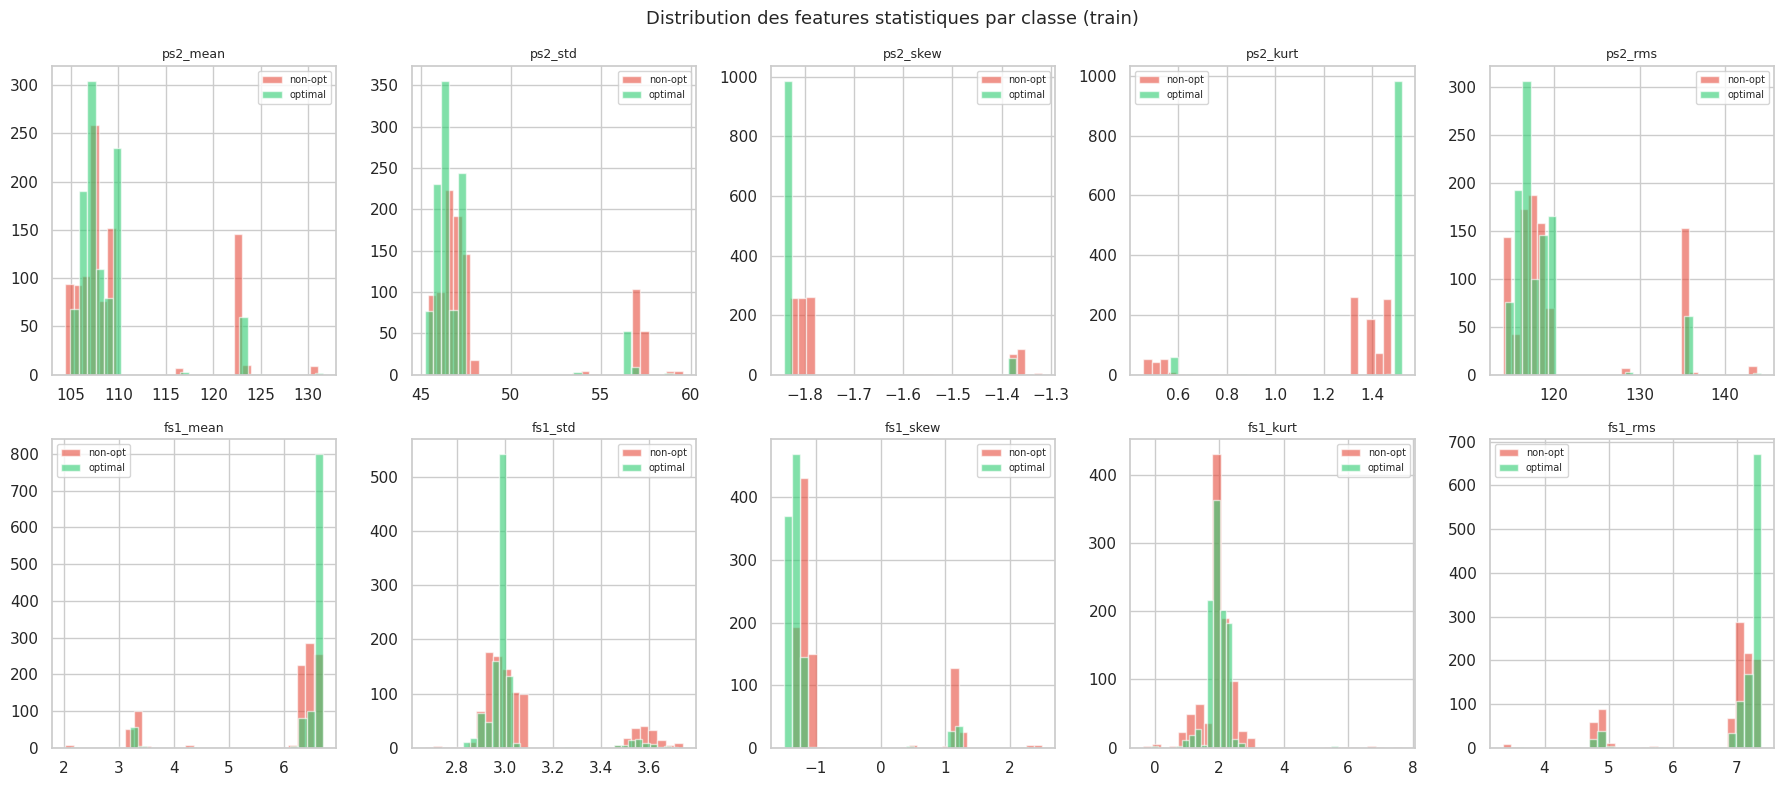

In [ ]:
stat_features = [c for c in X_train.columns if any(s in c for s in ['mean','std','rms','skew','kurt'])]

fig, axes = plt.subplots(2, len(stat_features)//2, figsize=(18, 8))
axes = axes.flat

for ax, feat in zip(axes, stat_features):
    for label, color in [(0, '#e74c3c'), (1, '#2ecc71')]:
        vals = X_train.loc[y_train == label, feat]
        ax.hist(vals, bins=30, alpha=0.6, color=color, label='non-opt' if label == 0 else 'optimal')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Distribution des features statistiques par classe (train)', fontsize=13)
plt.tight_layout()
plt.show()

# Ce graphe montre que plusieurs features statistiques PS2/FS1 ont des distributions décalées entre classes optimal et non-opt (notamment mean, std, rms, kurt), confirmant leur pouvoir discriminant pour prédire l’état de la valve.

## 3. Pouvoir discriminant — test de Mann-Whitney

In [6]:
from scipy import stats

scores = []
for col in X_train.columns:
    opt     = X_train.loc[y_train == 1, col]
    nonopt  = X_train.loc[y_train == 0, col]
    stat, p = stats.mannwhitneyu(opt, nonopt, alternative='two-sided')
    scores.append({'feature': col, 'p_value': p, 'significant': p < 0.05})

df_scores = pd.DataFrame(scores).sort_values('p_value')
print(f'Features significatives (p<0.05) : {df_scores["significant"].sum()} / {len(df_scores)}')
print()
print(df_scores.head(15).to_string(index=False))

Features significatives (p<0.05) : 34 / 41

            feature       p_value  significant
          ps2_fft_8 1.894603e-292         True
          ps2_fft_6 7.841712e-283         True
          ps2_fft_7 2.511298e-262         True
           ps2_kurt 4.719405e-262         True
           ps2_skew 2.153781e-261         True
           fs1_skew 3.413943e-162         True
          ps2_fft_5 2.728985e-108         True
          fs1_fft_0  2.789452e-91         True
           fs1_mean  2.791649e-91         True
          ps2_fft_1  1.114637e-90         True
            fs1_q25  2.612834e-79         True
         fs1_median  3.313533e-78         True
          ps2_fft_9  2.041165e-77         True
          ps2_fft_2  6.424956e-77         True
fs1_spectral_energy  1.127674e-76         True


## 4. Matrice de corrélation des features (train)

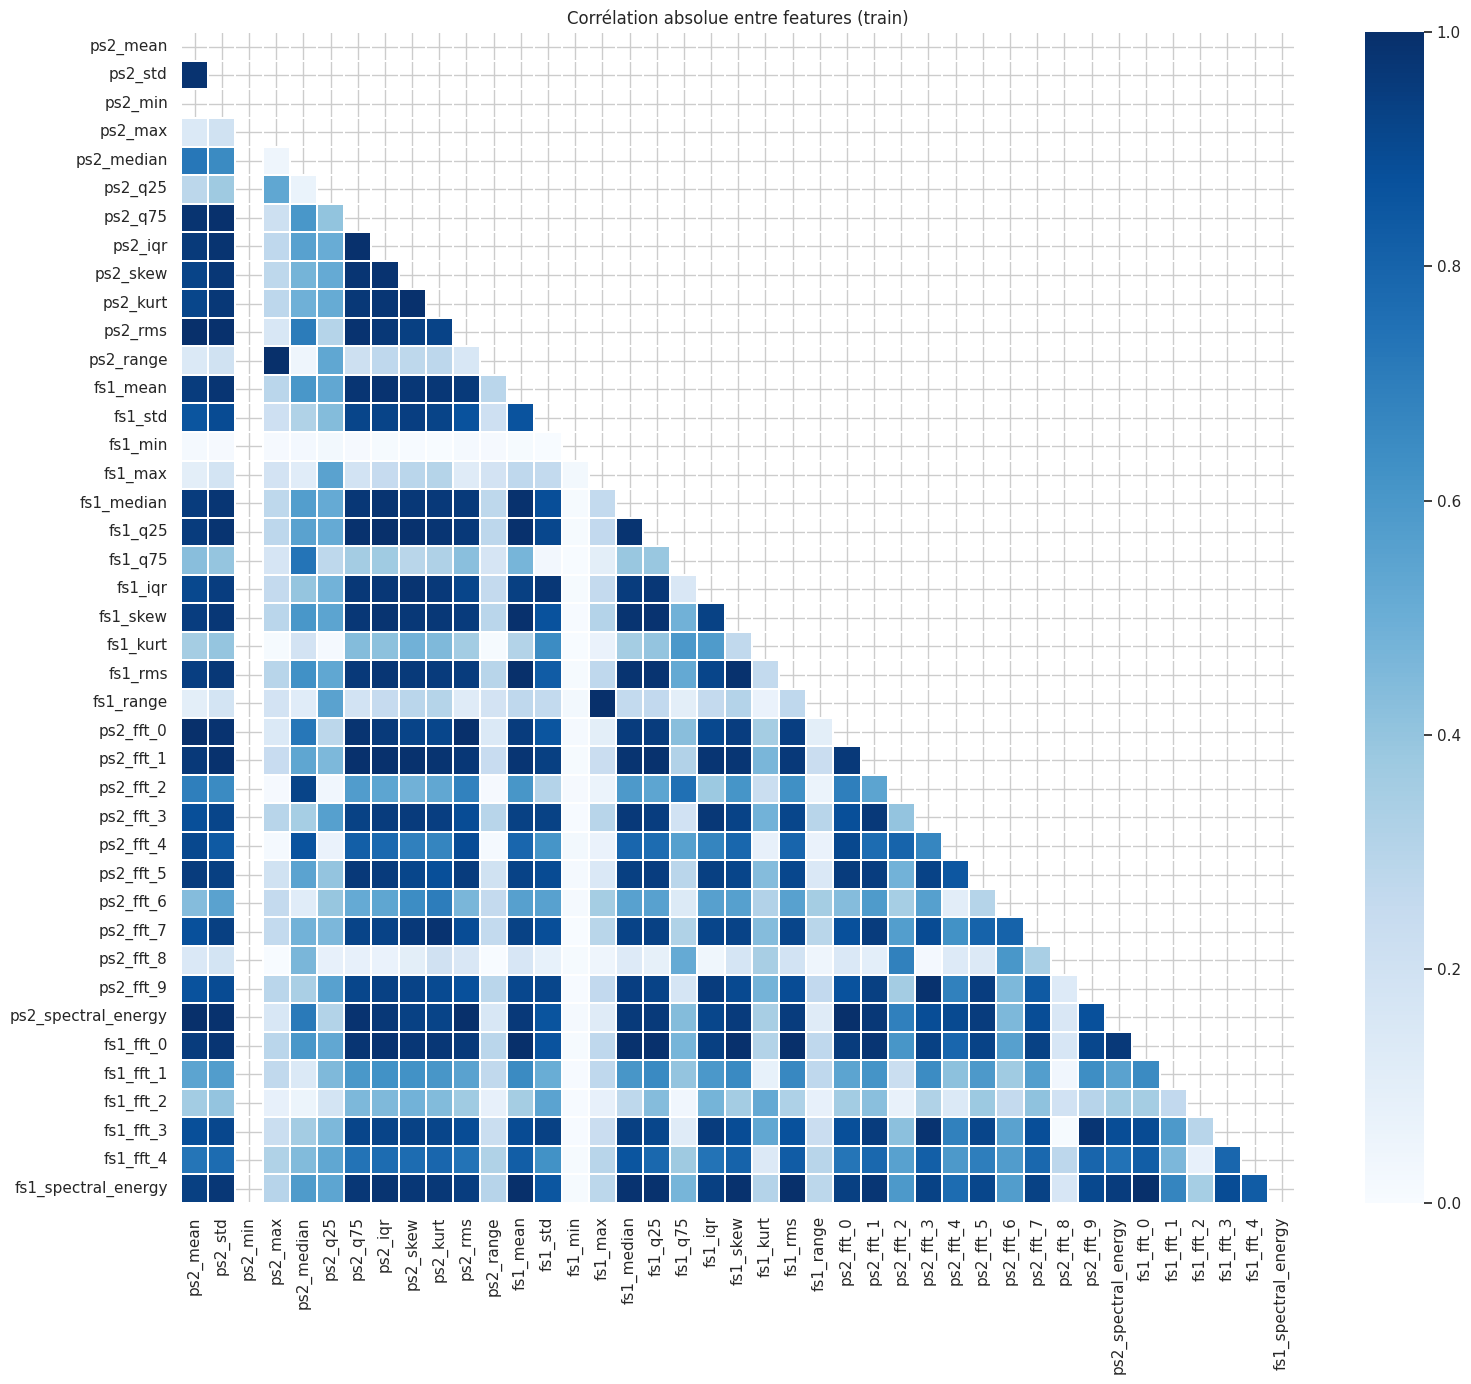

Paires avec corrélation > 0.95 : 147
  ps2_fft_0 ↔ ps2_mean : 1.000
  fs1_fft_0 ↔ fs1_mean : 1.000
  ps2_max ↔ ps2_range : 1.000
  fs1_max ↔ fs1_range : 1.000
  ps2_rms ↔ ps2_spectral_energy : 1.000
  ps2_mean ↔ ps2_spectral_energy : 1.000
  ps2_fft_0 ↔ ps2_spectral_energy : 1.000
  ps2_mean ↔ ps2_rms : 0.999
  ps2_fft_0 ↔ ps2_rms : 0.999
  fs1_fft_0 ↔ fs1_spectral_energy : 0.998


In [ ]:
corr = X_train.corr().abs()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='Blues', vmin=0, vmax=1, linewidths=0.3)
plt.title('Corrélation absolue entre features (train)')
plt.tight_layout()
plt.show()

# Paires très corrélées
high_corr = [(c1, c2, corr.loc[c1, c2]) for c1 in corr.columns for c2 in corr.columns
             if c1 < c2 and corr.loc[c1, c2] > 0.95]
print(f'Paires avec corrélation > 0.95 : {len(high_corr)}')
for c1, c2, v in sorted(high_corr, key=lambda x: -x[2])[:10]:
    print(f'  {c1} ↔ {c2} : {v:.3f}')

# Cette matrice de corrélation montre une redondance élevée entre plusieurs features (notamment mean/rms et certaines composantes FFT/énergies), ce qui est attendu sur des signaux cycliques et reste gérable par des modèles ensemblistes comme Random Forest/LightGBM.

## 5. Importance des features (Random Forest rapide)

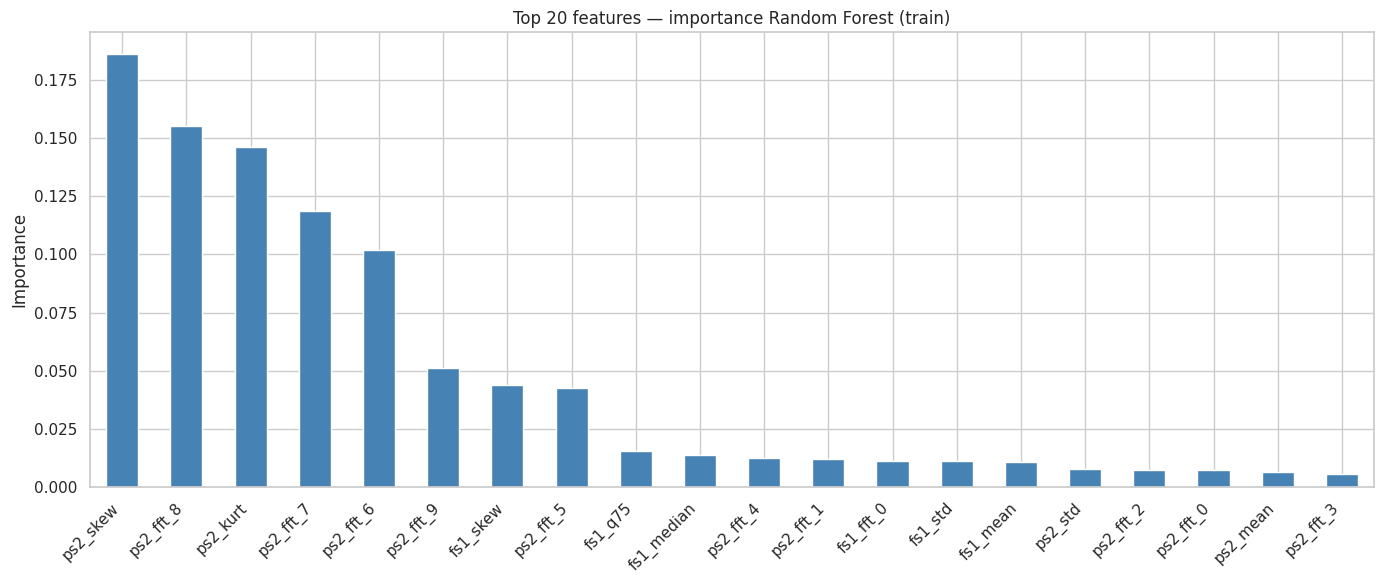

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train)  # fit uniquement sur train

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_tr_scaled, y_train)

importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
importance.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 features — importance Random Forest (train)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Ce graphique d’importance Random Forest montre que les variables les plus informatives pour la prédiction sont surtout des features PS2 (notamment ps2_skew, ps2_fft_8, ps2_kurt), ce qui indique que la pression porte l’essentiel du signal discriminant sur le train set.

## Conclusions

- **41 features** construites : 12 stats × 2 capteurs + FFT (10 PS2 + 5 FS1) + 2 énergies spectrales
- Aucun NaN
- La majorité des features sont significativement différentes entre les deux classes (Mann-Whitney)
- Les features PS2 (pression) semblent plus discriminantes que FS1 (débit) selon l'importance RF
- Quelques features très corrélées (mean/rms notamment) — les modèles ensemblistes gèrent bien la redondance